##Deep Learning, DL Models, and Applications


```python
# Task 9: Anchor-Free Object Detection (YOLOv8-style) Loss Backpropagation
# ● Objective: Architect state-of-the-art multi-task object localization pipelines by tracking
# regression outputs and classification predictions simultaneously.
# ● Required Tech Stack: PyTorch, OpenCV, NumPy, Matplotlib.
# ● Task Description: Students will write a custom loss-tracking module for an anchor-free
# object detector. The module must implement Complete Intersection over Union (CIoU)
# bounding box regression loss, compute classification loss, and handle complex assignment
# strategies to match target labels with dynamic network outputs.
```

In [230]:
#Step 1: Import Libraries
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [231]:
#Step 2: Define CIoU Loss Function
def compute_ciou(pred_box, target_box, eps=1e-7):

    b1_x1, b1_y1, b1_x2, b1_y2 = pred_box.unbind(-1)
    b2_x1, b2_y1, b2_x2, b2_y2 = target_box.unbind(-1)

    inter_x1 = torch.max(b1_x1, b2_x1)
    inter_y1 = torch.max(b1_y1, b2_y1)
    inter_x2 = torch.min(b1_x2, b2_x2)
    inter_y2 = torch.min(b1_y2, b2_y2)

    inter_area = (
        (inter_x2 - inter_x1).clamp(min=0)
        * (inter_y2 - inter_y1).clamp(min=0)
    )

    w1 = (b1_x2 - b1_x1).clamp(min=0)
    h1 = (b1_y2 - b1_y1).clamp(min=0)

    w2 = (b2_x2 - b2_x1).clamp(min=0)
    h2 = (b2_y2 - b2_y1).clamp(min=0)

    area1 = w1 * h1
    area2 = w2 * h2

    union = area1 + area2 - inter_area + eps
    iou = inter_area / union

    cw = torch.max(b1_x2, b2_x2) - torch.min(b1_x1, b2_x1)
    ch = torch.max(b1_y2, b2_y2) - torch.min(b1_y1, b2_y1)

    c2 = cw**2 + ch**2 + eps

    b1_cx = (b1_x1 + b1_x2) / 2
    b1_cy = (b1_y1 + b1_y2) / 2

    b2_cx = (b2_x1 + b2_x2) / 2
    b2_cy = (b2_y1 + b2_y2) / 2

    rho2 = (b1_cx - b2_cx)**2 + (b1_cy - b2_cy)**2

    v = (4/(np.pi**2)) * torch.pow(
        torch.atan(w2/(h2+eps)) -
        torch.atan(w1/(h1+eps)),2
    )

    with torch.no_grad():
        alpha = v/(1-iou+v+eps)

    ciou = iou - (rho2/c2 + alpha*v)

    return 1-ciou.mean()

In [232]:
#Step 3: Create Custom Loss Class
class SimpleAnchorFreeLoss(nn.Module):

    def __init__(self):
        super().__init__()

        self.bce = nn.BCEWithLogitsLoss()

    def forward(self,pred_boxes,pred_cls,gt_boxes,gt_cls):

        loss_box = compute_ciou(pred_boxes,gt_boxes)

        loss_cls = self.bce(pred_cls,gt_cls)

        total_loss = loss_box + loss_cls

        return total_loss,loss_box,loss_cls

In [233]:
#Step 4: Create Dummy Data
torch.manual_seed(42)

pred_boxes = nn.Parameter(torch.tensor([
    [10.,10.,40.,40.],
    [50.,50.,80.,80.]
]))

pred_cls = nn.Parameter(torch.tensor([
    [2.,-1.],
    [-1.,2.]
]))

gt_boxes = torch.tensor([
    [12.,12.,42.,42.],
    [52.,52.,82.,82.]
])

gt_cls = torch.tensor([
    [1.,0.],
    [0.,1.]
])

In [234]:
#Step 5: Initialize Loss and Optimizer
criterion = SimpleAnchorFreeLoss()

optimizer = torch.optim.Adam(
    [pred_boxes,pred_cls],
    lr=0.1
)

In [235]:
#Step 6: Training Loop
loss_history = []

for epoch in range(3):

    optimizer.zero_grad()

    total_loss,loss_box,loss_cls = criterion(
        pred_boxes,
        pred_cls,
        gt_boxes,
        gt_cls
    )

    total_loss.backward()

    optimizer.step()

    loss_history.append(total_loss.item())

    print(f"Epoch {epoch+1}")
    print(f"Box Loss : {loss_box.item():.4f}")
    print(f"Class Loss : {loss_cls.item():.4f}")
    print(f"Total Loss : {total_loss.item():.4f}")

Epoch 1
Box Loss : 0.2323
Class Loss : 0.2201
Total Loss : 0.4523
Epoch 2
Box Loss : 0.2221
Class Loss : 0.2014
Total Loss : 0.4235
Epoch 3
Box Loss : 0.2117
Class Loss : 0.1842
Total Loss : 0.3960


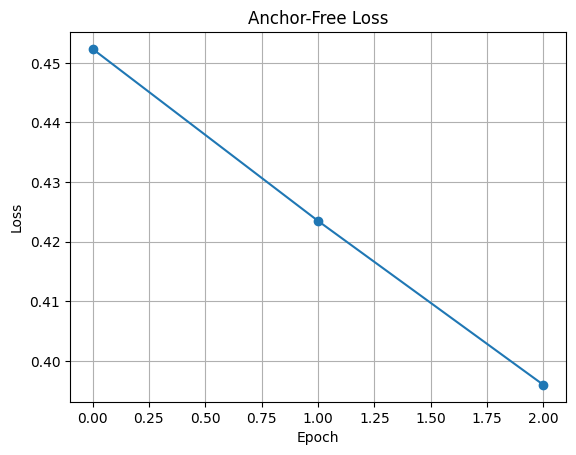

In [236]:
#Step 7: Plot Loss Curve
plt.plot(loss_history,marker="o")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Anchor-Free Loss")

plt.grid(True)

plt.show()